# Predicting Students' Dropout and Academic Success

**Research question:** How well can machine learning models predict student dropout and academic success, and how much does early academic performance improve prediction compared with enrollment-only information?

This notebook uses the UCI *Predict Students' Dropout and Academic Success* dataset. The official target is a three-class outcome: `Dropout`, `Enrolled`, and `Graduate`.

The central design idea is a **prediction timing comparison**:

- **Enrollment-only:** background, application, demographic, and socio-economic information known around enrollment.
- **+ 1st semester:** enrollment information plus first-semester academic performance.
- **+ 1st + 2nd semester:** all available features, including first- and second-semester performance.

This distinction matters for real-world use. A model using semester performance may predict better, but it cannot be deployed before those semester results exist.


## 1. Problem Definition

The applied problem is early identification of students at risk of dropping out or failing to progress successfully. This is framed as a supervised **multi-class classification** task.

Sub-questions:

1. Which model performs best for predicting `Dropout`, `Enrolled`, and `Graduate`?
2. How much does adding first- and second-semester performance improve prediction over enrollment-only information?
3. Does class imbalance handling improve recall for the minority or intervention-relevant classes?
4. Which features are most strongly associated with dropout and academic success predictions?

The main metric is **macro F1**, because it gives equal weight to all three classes and does not let the larger `Graduate` class dominate the evaluation. Accuracy and weighted F1 are reported as supporting metrics. Per-class recall is used to inspect whether the model identifies `Dropout` students effectively.


In [2]:
# Reproducibility and package setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon
from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
FIG_DIR = PROJECT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

TARGET_ORDER = ["Dropout", "Enrolled", "Graduate"]

def get_scores(y_true, y_pred):
    """Return the same evaluation metrics for every model."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_ORDER, zero_division=0
    )
    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    for label, rec in zip(TARGET_ORDER, recall):
        row[f"recall_{label.lower()}"] = rec
    return row


## 2. Data Loading And Basic Checks


In [3]:
# Fetch dataset from UCI
students = fetch_ucirepo(id=697)
X_raw = students.data.features.copy()
y_raw = students.data.targets.copy()
variables = students.variables.copy()

df = pd.concat([X_raw, y_raw], axis=1)
df.head()


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Basic checks
print("Shape:", df.shape)
print("Feature shape:", X_raw.shape)
print("Target columns:", y_raw.columns.tolist())
print("Duplicate rows:", df.duplicated().sum())
print("Missing values total:", int(df.isna().sum().sum()))
print("Target distribution:")
print(y_raw["Target"].value_counts())
print("Target proportions:")
print((y_raw["Target"].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

variables.head(12)


Shape: (4424, 37)
Feature shape: (4424, 36)
Target columns: ['Target']
Duplicate rows: 0
Missing values total: 0
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target proportions:
Target
Graduate    49.93%
Dropout     32.12%
Enrolled    17.95%
Name: proportion, dtype: object


,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


## 3. Feature Timing Design

The dataset contains both enrollment-time information and academic performance after the first and second semesters. For a realistic early-warning system, these groups must be separated.


In [5]:
sem1_features = [col for col in X_raw.columns if "1st sem" in col]
sem2_features = [col for col in X_raw.columns if "2nd sem" in col]
enrollment_features = [col for col in X_raw.columns if col not in sem1_features + sem2_features]

feature_sets = {
    "Enrollment only": enrollment_features,
    "+ 1st semester": enrollment_features + sem1_features,
    "+ 1st + 2nd semester": enrollment_features + sem1_features + sem2_features,
}

print("Enrollment features:", len(enrollment_features), enrollment_features)
print("First-semester features:", len(sem1_features), sem1_features)
print("Second-semester features:", len(sem2_features), sem2_features)
print("All feature counts:", {name: len(cols) for name, cols in feature_sets.items()})


Enrollment features: 24 ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Unemployment rate', 'Inflation rate', 'GDP']
First-semester features: 6 ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)']
Second-semester features: 6 ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (g

In [6]:
# Stable train/test split used for all feature-timing experiments
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_raw,
    y_raw["Target"],
    test_size=0.20,
    stratify=y_raw["Target"],
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train_all.shape, "Test shape:", X_test_all.shape)
print("Train class proportions:")
print((y_train.value_counts(normalize=True).reindex(TARGET_ORDER) * 100).round(2).astype(str) + "%")
print("Test class proportions:")
print((y_test.value_counts(normalize=True).reindex(TARGET_ORDER) * 100).round(2).astype(str) + "%")


Train shape: (3539, 36) Test shape: (885, 36)
Train class proportions:
Target
Dropout     32.13%
Enrolled    17.94%
Graduate    49.93%
Name: proportion, dtype: object
Test class proportions:
Target
Dropout     32.09%
Enrolled    17.97%
Graduate    49.94%
Name: proportion, dtype: object


## 4. Exploratory Data Analysis

The EDA checks class imbalance and explores relationships between the target and enrollment characteristics, course choice, and early academic performance. These plots are descriptive rather than causal.


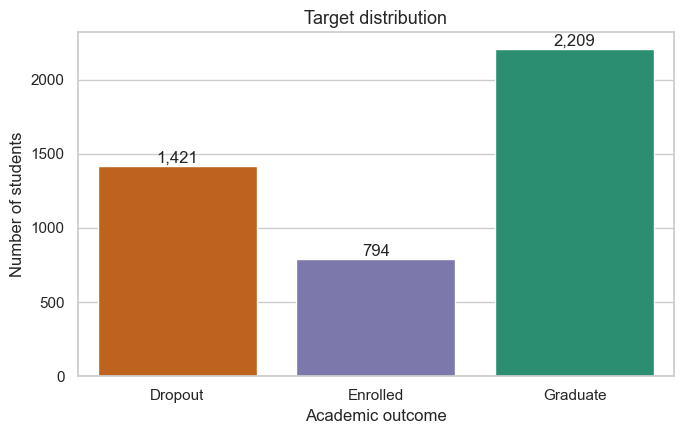

In [7]:
# Target distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df, x="Target", order=TARGET_ORDER, palette=["#d95f02", "#7570b3", "#1b9e77"], ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("Academic outcome")
ax.set_ylabel("Number of students")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG_DIR / "students_target_distribution.png", dpi=200)
plt.show()


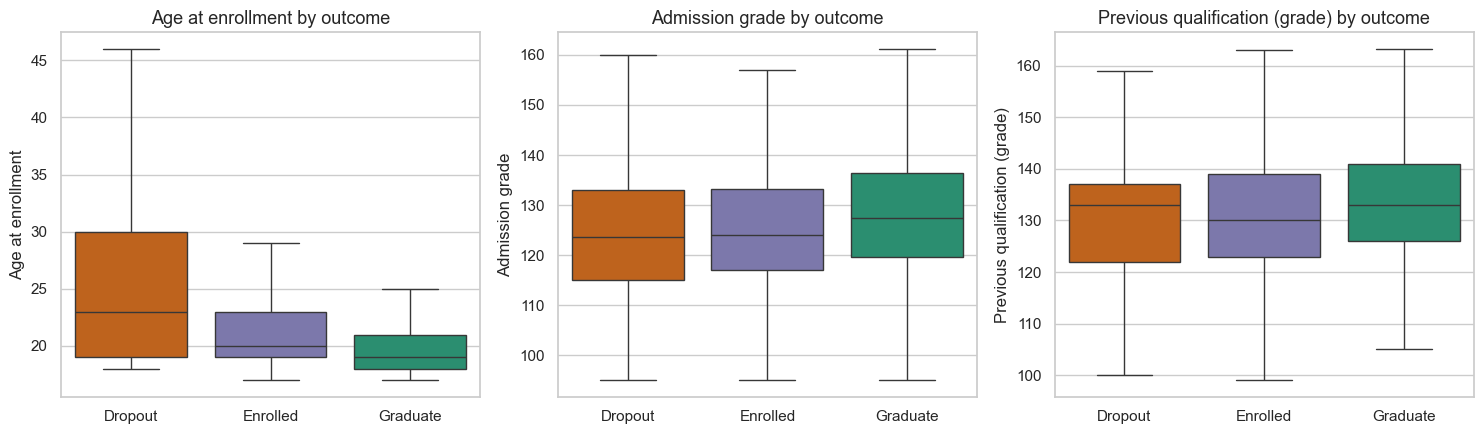

In [8]:
# Enrollment numeric variables by outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["Age at enrollment", "Admission grade", "Previous qualification (grade)"]):
    sns.boxplot(data=df, x="Target", y=col, order=TARGET_ORDER, palette=["#d95f02", "#7570b3", "#1b9e77"], showfliers=False, ax=ax)
    ax.set_title(f"{col} by outcome")
    ax.set_xlabel("")
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(FIG_DIR / "students_enrollment_numeric_by_target.png", dpi=200)
plt.show()


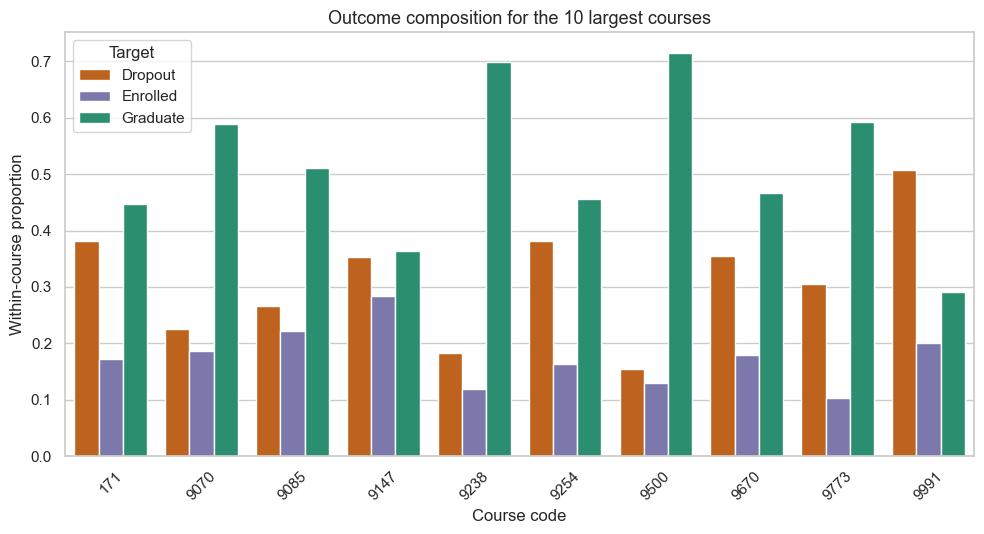

In [9]:
# Top courses by target composition
course_counts = df["Course"].value_counts().head(10).index
top_course_df = df[df["Course"].isin(course_counts)].copy()
course_target = (
    pd.crosstab(top_course_df["Course"], top_course_df["Target"], normalize="index")
    .reindex(columns=TARGET_ORDER)
    .reset_index()
    .melt(id_vars="Course", var_name="Target", value_name="proportion")
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=course_target, x="Course", y="proportion", hue="Target", hue_order=TARGET_ORDER, palette=["#d95f02", "#7570b3", "#1b9e77"], ax=ax)
ax.set_title("Outcome composition for the 10 largest courses")
ax.set_xlabel("Course code")
ax.set_ylabel("Within-course proportion")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "students_course_target_composition.png", dpi=200)
plt.show()


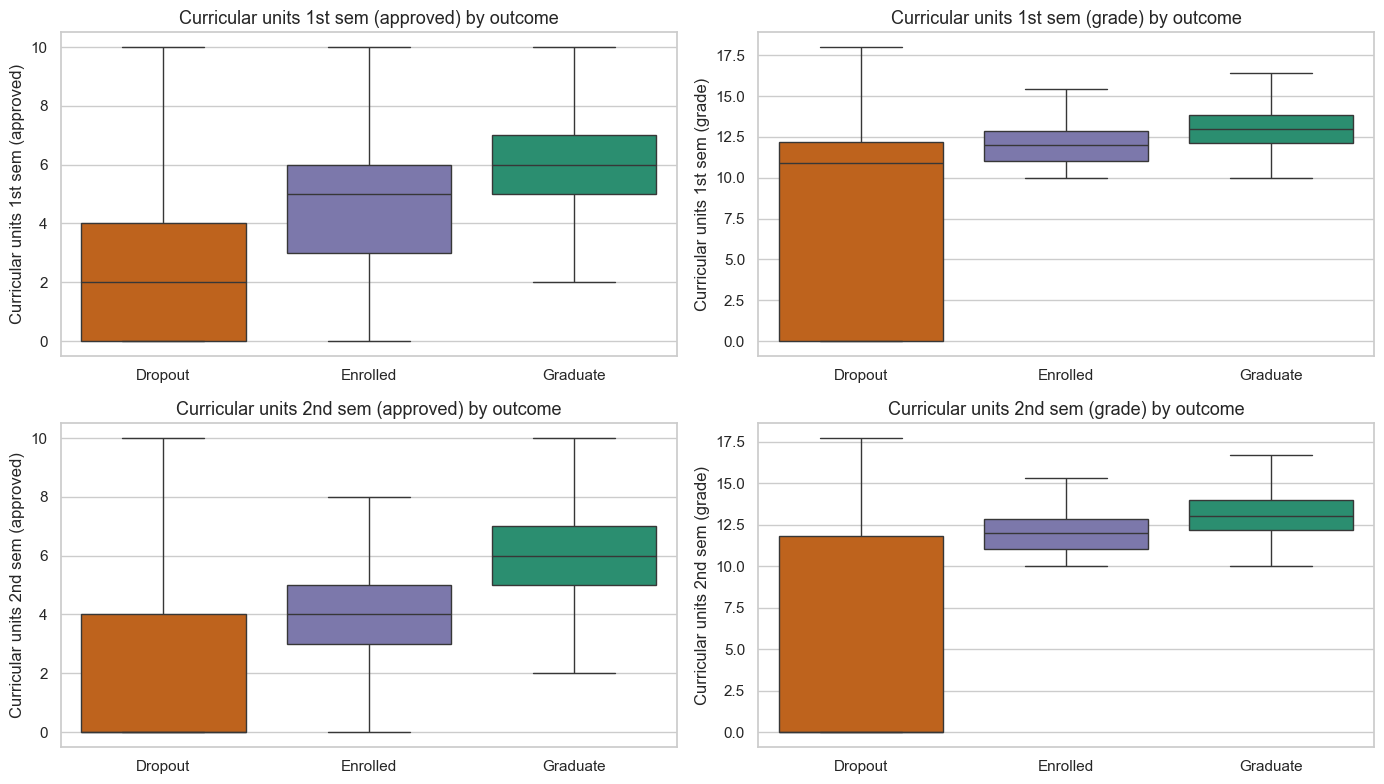

In [10]:
# Early academic performance by outcome
performance_cols = [
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), performance_cols):
    sns.boxplot(data=df, x="Target", y=col, order=TARGET_ORDER, palette=["#d95f02", "#7570b3", "#1b9e77"], showfliers=False, ax=ax)
    ax.set_title(f"{col} by outcome")
    ax.set_xlabel("")
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(FIG_DIR / "students_semester_performance_by_target.png", dpi=200)
plt.show()


## 5. Preprocessing And Model Setup

Integer-coded administrative variables are treated as categorical when their values are codes rather than meaningful magnitudes. Grades, ages, economic indicators, application order, and curricular unit counts are treated as numeric.


In [11]:
categorical_features_all = [
    "Marital Status", "Application mode", "Course", "Daytime/evening attendance",
    "Previous qualification", "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]

numeric_features_all = [col for col in X_raw.columns if col not in categorical_features_all]

print("Categorical features:", len(categorical_features_all), categorical_features_all)
print("Numeric features:", len(numeric_features_all), numeric_features_all)

def make_preprocessor(selected_columns):
    cat_cols = [col for col in selected_columns if col in categorical_features_all]
    num_cols = [col for col in selected_columns if col in numeric_features_all]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("scaler", StandardScaler())]), num_cols),
            ("cat", Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
        ],
        remainder="drop",
    )


Categorical features: 17 ['Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
Numeric features: 19 ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', '

In [12]:
model_specs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=2000, solver="liblinear", multi_class="ovr", random_state=RANDOM_STATE),
        "param_grid": {
            "model__C": [0.3, 1.0, 3.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "param_grid": {
            "model__max_depth": [4, 8, None],
            "model__min_samples_leaf": [5, 15],
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {
            "model__n_neighbors": [5, 11],
            "model__weights": ["uniform", "distance"],
        },
    },
    "SVM (RBF)": {
        "estimator": SVC(kernel="rbf", random_state=RANDOM_STATE),
        "param_grid": {
            "model__C": [1, 10],
            "model__gamma": ["scale"],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=RANDOM_STATE),
        "param_grid": {
            "model__max_depth": [None, 12],
            "model__min_samples_leaf": [2, 5],
            "model__class_weight": [None, "balanced"],
        },
    },
    "MLP": {
        "estimator": MLPClassifier(max_iter=500, early_stopping=False, random_state=RANDOM_STATE),
        "param_grid": {
            "model__hidden_layer_sizes": [(50,), (80,)],
            "model__alpha": [0.0001, 0.001],
        },
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}


## 6. Model Comparison And Feature-Timing Experiment

Each feature set is evaluated with the same family of classroom models. Hyperparameters are selected with cross-validation on the training set only, using macro F1 as the refit metric.


In [13]:
cv_rows = []
test_rows = []
best_params_rows = []
fitted_models = {}
cv_scores_by_experiment = {}

for feature_set_name, columns in feature_sets.items():
    X_train = X_train_all[columns]
    X_test = X_test_all[columns]
    preprocess = make_preprocessor(columns)

    dummy_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]) #加入基线模型以评估特征集的预测能力
    dummy_scores = cross_validate(dummy_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1) #基线模型的交叉验证分数用于后续比较
    dummy_pipe.fit(X_train, y_train) #基线模型拟合以获得测试集分数
    key = (feature_set_name, "Dummy majority") #基线模型的实验标识符
    fitted_models[key] = dummy_pipe #保存基线模型以供后续分析
    cv_scores_by_experiment[key] = dummy_scores #保存基线模型的交叉验证分数以供后续统计比较
    cv_rows.append({
        "feature_set": feature_set_name,
        "model": "Dummy majority",
        "accuracy_mean": dummy_scores["test_accuracy"].mean(),
        "macro_f1_mean": dummy_scores["test_macro_f1"].mean(),
        "macro_f1_std": dummy_scores["test_macro_f1"].std(),
        "weighted_f1_mean": dummy_scores["test_weighted_f1"].mean(),
    }) #记录基线模型的交叉验证分数以供后续比较
    y_pred = dummy_pipe.predict(X_test)
    test_rows.append({"feature_set": feature_set_name, "model": "Dummy majority", **get_scores(y_test, y_pred)})
    best_params_rows.append({"feature_set": feature_set_name, "model": "Dummy majority", "best_params": "strategy='most_frequent'"}) #记录基线模型的参数以供后续分析

    for model_name, spec in model_specs.items():
        pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", spec["estimator"]),
        ])
        search = GridSearchCV(
            pipe,
            spec["param_grid"],
            scoring=scoring,
            refit="macro_f1",
            cv=cv,
            n_jobs=1,
            return_train_score=False,
        )
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        scores = cross_validate(best_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1) #使用最佳模型进行交叉验证以获得每个折叠的分数，供后续统计比较
        key = (feature_set_name, model_name) #实验标识符
        fitted_models[key] = best_pipe #保存每个实验的最佳模型
        cv_scores_by_experiment[key] = scores #保存每个实验的交叉验证分数以供后续统计比较
        cv_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "macro_f1_mean": scores["test_macro_f1"].mean(),
            "macro_f1_std": scores["test_macro_f1"].std(),
            "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        })
        y_pred = best_pipe.predict(X_test)
        test_rows.append({"feature_set": feature_set_name, "model": model_name, **get_scores(y_test, y_pred)})
        best_params_rows.append({"feature_set": feature_set_name, "model": model_name, "best_params": search.best_params_})

# cv_results = pd.DataFrame(cv_rows).sort_values(["feature_set", "macro_f1_mean"], ascending=[True, False])
test_results = pd.DataFrame(test_rows).sort_values("macro_f1", ascending=False)
# best_params = pd.DataFrame(best_params_rows)

test_results.head(21)


,feature_set,model,accuracy,macro_f1,weighted_f1,recall_dropout,recall_enrolled,recall_graduate
19,+ 1st + 2nd semester,Random Forest,0.750282,0.705109,0.757034,0.697183,0.591195,0.841629
18,+ 1st + 2nd semester,SVM (RBF),0.731073,0.691515,0.741686,0.679577,0.616352,0.805430
15,+ 1st + 2nd semester,Logistic Regression,0.742373,0.679824,0.742195,0.704225,0.459119,0.868778
8,+ 1st semester,Logistic Regression,0.729944,0.671462,0.730620,0.707746,0.459119,0.841629
11,+ 1st semester,SVM (RBF),0.708475,0.665625,0.719861,0.623239,0.591195,0.805430
12,+ 1st semester,Random Forest,0.708475,0.657053,0.714019,0.679577,0.496855,0.803167
16,+ 1st + 2nd semester,Decision Tree,0.733333,0.653992,0.722277,0.672535,0.364780,0.904977
20,+ 1st + 2nd semester,MLP,0.702825,0.642784,0.705244,0.690141,0.427673,0.809955
9,+ 1st semester,Decision Tree,0.717514,0.641526,0.709208,0.676056,0.358491,0.873303
13,+ 1st semester,MLP,0.680226,0.623024,0.682122,0.686620,0.408805,0.773756


In [14]:
# Best model per feature timing
best_by_feature_set = (
    test_results.sort_values("macro_f1", ascending=False)
    .groupby("feature_set", as_index=False)
    .first()
    .sort_values("macro_f1", ascending=False)
)
best_by_feature_set


,feature_set,model,accuracy,macro_f1,weighted_f1,recall_dropout,recall_enrolled,recall_graduate
0,+ 1st + 2nd semester,Random Forest,0.750282,0.705109,0.757034,0.697183,0.591195,0.841629
1,+ 1st semester,Logistic Regression,0.729944,0.671462,0.730620,0.707746,0.459119,0.841629
2,Enrollment only,Random Forest,0.598870,0.554553,0.606499,0.619718,0.402516,0.656109


In [15]:
# Statistical comparison of macro-F1 folds for best models across feature timings
best_keys = [(row["feature_set"], row["model"]) for _, row in best_by_feature_set.iterrows()]
reference_key = best_keys[0]
stats_rows = []
for key in best_keys[1:]:
    try:
        p_value = wilcoxon(
            cv_scores_by_experiment[reference_key]["test_macro_f1"],
            cv_scores_by_experiment[key]["test_macro_f1"],
        )
    except ValueError:
        p_value = np.nan, np.nan
    stats_rows.append({
        "comparison": f"{key[0]} / {key[1]} vs {reference_key[0]} / {reference_key[1]}",
        "p_value": p_value,
    })

pd.DataFrame(stats_rows)


,comparison,p_value
0,+ 1st semester / Logistic Regression vs + 1st ...,"(0.0, 0.0625)"
1,Enrollment only / Random Forest vs + 1st + 2nd...,"(0.0, 0.0625)"


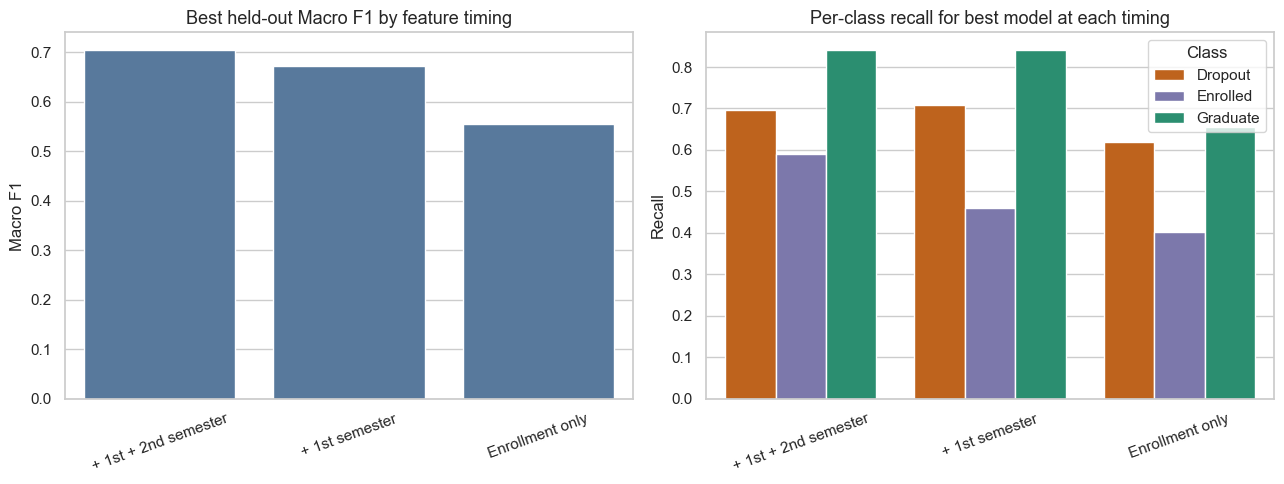

In [16]:
# Visual comparison of best model at each feature timing
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=best_by_feature_set, x="feature_set", y="macro_f1", color="#4c78a8", ax=axes[0])
axes[0].set_title("Best held-out Macro F1 by feature timing")
axes[0].set_xlabel("")
axes[0].set_ylabel("Macro F1")
axes[0].tick_params(axis="x", rotation=20)

recall_long = best_by_feature_set.melt(
    id_vars=["feature_set", "model"],
    value_vars=["recall_dropout", "recall_enrolled", "recall_graduate"],
    var_name="class",
    value_name="recall",
)
recall_long["class"] = recall_long["class"].str.replace("recall_", "").str.title()
sns.barplot(data=recall_long, x="feature_set", y="recall", hue="class", palette=["#d95f02", "#7570b3", "#1b9e77"], ax=axes[1])
axes[1].set_title("Per-class recall for best model at each timing")
axes[1].set_xlabel("")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "students_feature_timing_model_comparison.png", dpi=200)
plt.show()


## 7. Class Imbalance Handling


In [24]:
# Compare imbalance strategies on the richest feature set.
imbalance_columns = feature_sets["+ 1st + 2nd semester"]
X_train_imb = X_train_all[imbalance_columns]
X_test_imb = X_test_all[imbalance_columns]
preprocess_imb = make_preprocessor(imbalance_columns)

imbalance_experiments = {
    "Logistic baseline": Pipeline(steps=[
        ("preprocess", preprocess_imb),
        ("model", LogisticRegression(max_iter=2000, solver="liblinear", multi_class="ovr", random_state=RANDOM_STATE)),
    ]),# 无平衡处理的逻辑回归基线模型
    "Logistic class_weight": Pipeline(steps=[
        ("preprocess", preprocess_imb),
        ("model", LogisticRegression(max_iter=2000, solver="liblinear", multi_class="ovr", class_weight="balanced", random_state=RANDOM_STATE)),
    ]), #使用class_weight='balanced'参数的逻辑回归模型，以调整类别权重来处理不平衡问题
    "Logistic random oversampling": ImbPipeline(steps=[
        ("preprocess", preprocess_imb),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=2000, solver="liblinear", multi_class="ovr", random_state=RANDOM_STATE)),
    ]), #使用RandomOverSampler进行随机过采样的逻辑回归模型，通过在训练数据中增加少数类样本来处理不平衡问题
    "Random Forest baseline": Pipeline(steps=[
        ("preprocess", preprocess_imb),
        ("model", RandomForestClassifier(n_estimators=250, min_samples_leaf=2, n_jobs=1, random_state=RANDOM_STATE)),
    ]), # 无平衡处理的随机森林基线模型
    "Random Forest class_weight": Pipeline(steps=[
        ("preprocess", preprocess_imb),
        ("model", RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE)),
    ]), #使用class_weight='balanced'参数的随机森林模型，以调整类别权重来处理不平衡问题
}

imbalance_rows = []
imbalance_fitted = {}
for name, pipe in imbalance_experiments.items():
    scores = cross_validate(pipe, X_train_imb, y_train, cv=cv, scoring=scoring, n_jobs=1)
    pipe.fit(X_train_imb, y_train)
    imbalance_fitted[name] = pipe
    y_pred = pipe.predict(X_test_imb)
    imbalance_rows.append({
        "experiment": name,
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        **get_scores(y_test, y_pred),
    })

imbalance_results = pd.DataFrame(imbalance_rows).sort_values("macro_f1", ascending=False)
imbalance_results


,experiment,cv_macro_f1_mean,cv_macro_f1_std,accuracy,macro_f1,weighted_f1,recall_dropout,recall_enrolled,recall_graduate
4,Random Forest class_weight,0.710272,0.020116,0.762712,0.704124,0.760667,0.725352,0.490566,0.884615
2,Logistic random oversampling,0.701546,0.014471,0.734463,0.692388,0.744713,0.697183,0.597484,0.807692
1,Logistic class_weight,0.703960,0.010973,0.750282,0.689085,0.749706,0.704225,0.477987,0.877828
0,Logistic baseline,0.689720,0.019276,0.755932,0.667147,0.739543,0.739437,0.314465,0.925339
3,Random Forest baseline,0.666072,0.027015,0.764972,0.662565,0.738633,0.771127,0.251572,0.945701


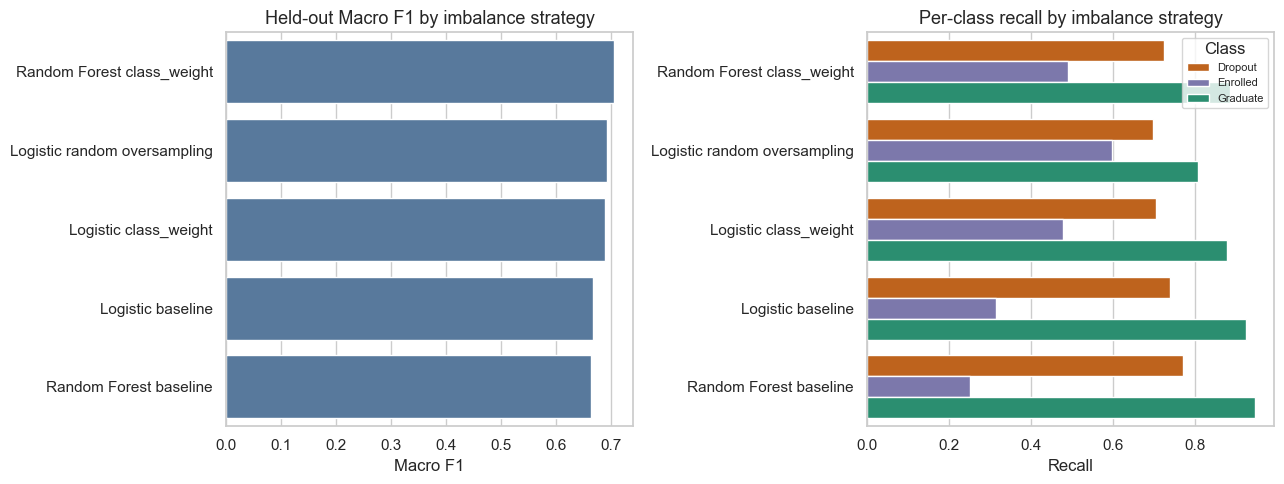

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=imbalance_results, y="experiment", x="macro_f1", color="#4c78a8", ax=axes[0]) #总体性能比较，显示每个不平衡处理策略的宏平均F1分数
axes[0].set_title("Held-out Macro F1 by imbalance strategy")
axes[0].set_xlabel("Macro F1")
axes[0].set_ylabel("")

imb_recall = imbalance_results.melt(
    id_vars="experiment",
    value_vars=["recall_dropout", "recall_enrolled", "recall_graduate"],
    var_name="class",
    value_name="recall",
)
imb_recall["class"] = imb_recall["class"].str.replace("recall_", "").str.title()
sns.barplot(data=imb_recall, y="experiment", x="recall", hue="class", palette=["#d95f02", "#7570b3", "#1b9e77"], ax=axes[1])
axes[1].set_title("Per-class recall by imbalance strategy")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")
axes[1].legend(title="Class", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "students_imbalance_strategy_comparison.png", dpi=200)
plt.show()


## 8. Best Model Diagnostics


Best held-out experiment: + 1st + 2nd semester / Random Forest
Best held-out metrics:


,feature_set,model,accuracy,macro_f1,weighted_f1,recall_dropout,recall_enrolled,recall_graduate
19,+ 1st + 2nd semester,Random Forest,0.750282,0.705109,0.757034,0.697183,0.591195,0.841629


Classification report:
              precision    recall  f1-score   support

     Dropout       0.83      0.70      0.76       284
    Enrolled       0.45      0.59      0.51       159
    Graduate       0.85      0.84      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.75      0.76       885



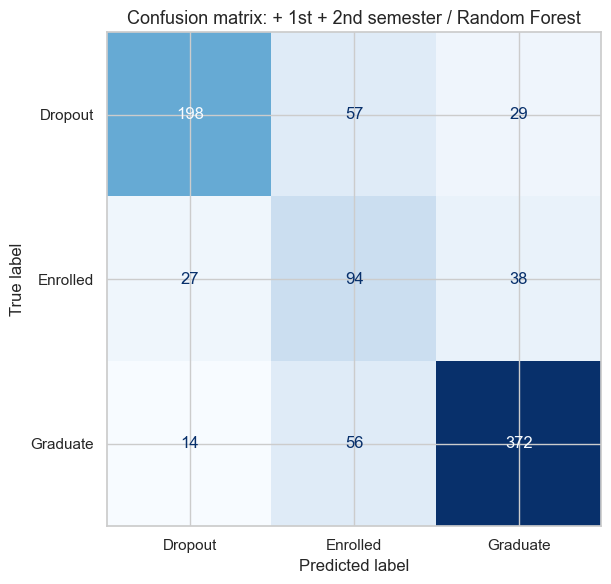

In [19]:
best_row = test_results.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_pipe = fitted_models[(best_feature_set, best_model_name)]
best_columns = feature_sets[best_feature_set]
y_pred_best = best_pipe.predict(X_test_all[best_columns])

print("Best held-out experiment:", best_feature_set, "/", best_model_name)
print("Best held-out metrics:")
display(pd.DataFrame([best_row]))
print("Classification report:")
print(classification_report(y_test, y_pred_best, labels=TARGET_ORDER, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    labels=TARGET_ORDER,
    display_labels=TARGET_ORDER,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Confusion matrix: {best_feature_set} / {best_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "students_best_model_confusion_matrix.png", dpi=200)
plt.show()


## 9. Feature Interpretation

Two interpretation views are used:

1. Logistic Regression coefficients for the `Dropout` class in the richest feature set.
2. Random Forest feature importance values in the richest feature set.

These are predictive associations and should not be interpreted as causal effects.


In [20]:
interpret_columns = feature_sets["+ 1st + 2nd semester"]
preprocess_interpret = make_preprocessor(interpret_columns)

logistic_interpret = Pipeline(steps=[
    ("preprocess", preprocess_interpret),
    ("model", LogisticRegression(max_iter=2000, solver="liblinear", multi_class="ovr", class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_interpret.fit(X_train_all[interpret_columns], y_train)

feature_names = logistic_interpret.named_steps["preprocess"].get_feature_names_out() #获得预处理步骤生成的特征名称列表，这些名称包括数值特征和经过独热编码处理的分类特征
classes = list(logistic_interpret.named_steps["model"].classes_)
dropout_index = classes.index("Dropout") #找到逻辑回归模型中对应于"Dropout"类别的索引位置，以便提取该类别的系数
dropout_coefs = logistic_interpret.named_steps["model"].coef_[dropout_index] #提取逻辑回归模型中对应于"Dropout"类别的系数，这些系数表示每个特征对预测"Dropout"类别的影响程度和方向
coef_table = pd.DataFrame({
    "feature": feature_names,
    "dropout_coefficient": dropout_coefs,
    "abs_coefficient": np.abs(dropout_coefs),
}).sort_values("abs_coefficient", ascending=False)

coef_table.head(20)


,feature,dropout_coefficient,abs_coefficient
16,num__Curricular units 2nd sem (approved),-2.032334,2.032334
185,cat__Mother's occupation_191,-1.745838,1.745838
58,cat__Course_9853,1.343938,1.343938
237,cat__Tuition fees up to date_1,-1.311356,1.311356
30,cat__Application mode_15,-1.224025,1.224025
236,cat__Tuition fees up to date_0,1.208811,1.208811
200,cat__Father's occupation_90,1.160511,1.160511
50,cat__Course_9130,1.142115,1.142115
158,cat__Mother's occupation_0,1.133942,1.133942
101,cat__Mother's qualification_4,-1.022332,1.022332


In [21]:
rf_interpret = Pipeline(steps=[
    ("preprocess", make_preprocessor(interpret_columns)),
    ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=1, random_state=RANDOM_STATE)),
])
rf_interpret.fit(X_train_all[interpret_columns], y_train)

rf_feature_names = rf_interpret.named_steps["preprocess"].get_feature_names_out()
importance_table = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_interpret.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

importance_table.head(20)


,feature,importance
16,num__Curricular units 2nd sem (approved),0.133665
17,num__Curricular units 2nd sem (grade),0.092645
10,num__Curricular units 1st sem (approved),0.088913
11,num__Curricular units 1st sem (grade),0.065347
15,num__Curricular units 2nd sem (evaluations),0.041564
9,num__Curricular units 1st sem (evaluations),0.035768
237,cat__Tuition fees up to date_1,0.032334
3,num__Age at enrollment,0.032025
236,cat__Tuition fees up to date_0,0.031752
2,num__Admission grade,0.030255


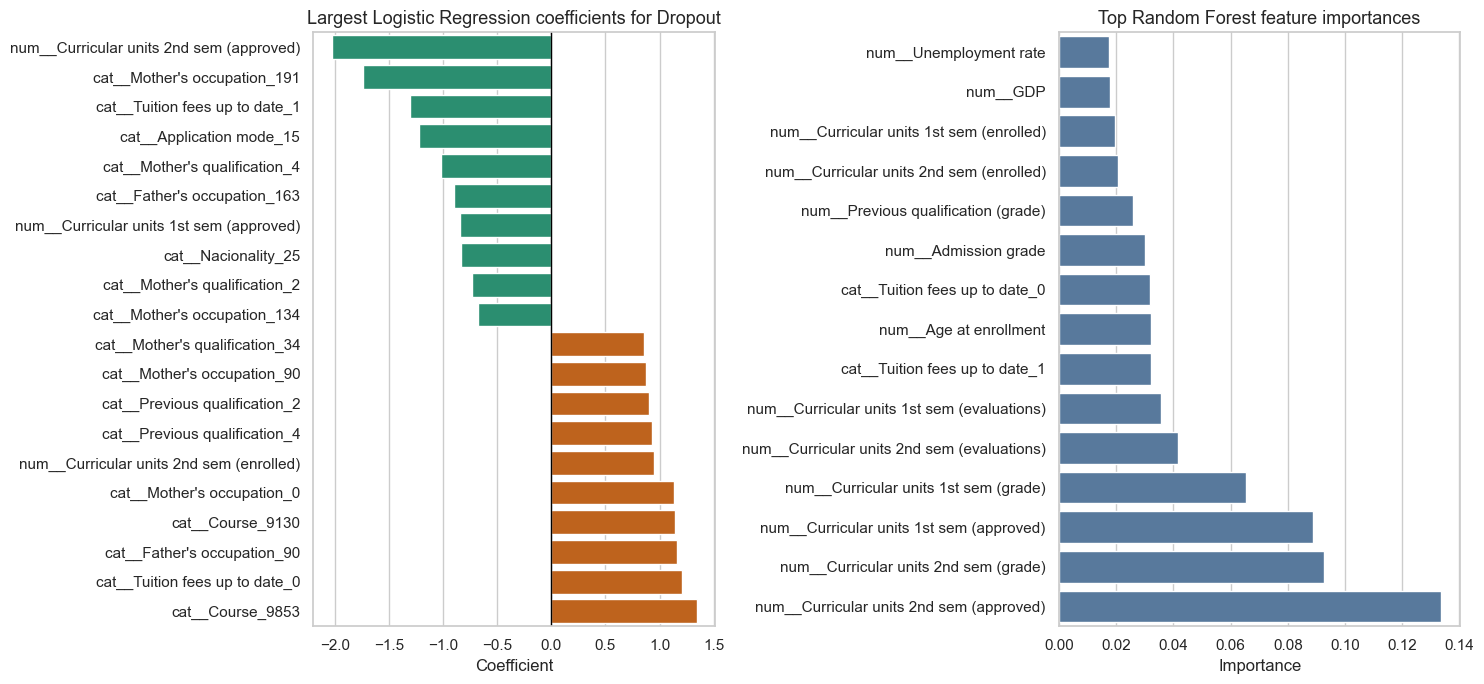

In [22]:
plot_coefs = pd.concat([
    coef_table.sort_values("dropout_coefficient").head(10),
    coef_table.sort_values("dropout_coefficient").tail(10),
]).sort_values("dropout_coefficient")

top_importance = importance_table.head(15).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(
    data=plot_coefs,
    x="dropout_coefficient",
    y="feature",
    hue=plot_coefs["dropout_coefficient"] > 0,
    dodge=False,
    palette={False: "#1b9e77", True: "#d95f02"},
    ax=axes[0],
)
axes[0].legend_.remove()
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Largest Logistic Regression coefficients for Dropout")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("")

sns.barplot(data=top_importance, x="importance", y="feature", color="#4c78a8", ax=axes[1])
axes[1].set_title("Top Random Forest feature importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "students_feature_interpretation.png", dpi=200)
plt.show()


## Final Discussion And Coursework Notes

Use the generated tables and figures for the short IEEE-style paper and poster/slides.

Key points to include:

- The official target is a three-class outcome: `Dropout`, `Enrolled`, and `Graduate`.
- The class distribution is imbalanced, especially for `Enrolled`, so macro F1 and per-class recall are more informative than accuracy alone.
- Enrollment-only prediction is the earliest deployment scenario, but semester performance variables should substantially improve prediction.
- First- and second-semester variables are not data leakage if the research question is explicitly framed as prediction after those semester results are available.
- `Dropout` recall matters because missing at-risk students is costly for an early-warning system.
- Feature importance and coefficients are predictive associations, not causal evidence.
- Sensitive socio-economic and demographic features require ethical discussion before real-world deployment.

Citation to include:

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.


In [23]:
# Final parameter record for reproducibility
parameter_rows = []
for (feature_set, model_name), pipe in fitted_models.items():
    parameter_rows.append({
        "feature_set": feature_set,
        "model": model_name,
        "parameters": pipe.named_steps["model"].get_params(),
    })

params_df = pd.DataFrame(parameter_rows)
params_df.head(20)


,feature_set,model,parameters
0,Enrollment only,Dummy majority,"{'constant': None, 'random_state': None, 'stra..."
1,Enrollment only,Logistic Regression,"{'C': 0.3, 'class_weight': 'balanced', 'dual':..."
2,Enrollment only,Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit..."
3,Enrollment only,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
4,Enrollment only,SVM (RBF),"{'C': 1, 'break_ties': False, 'cache_size': 20..."
5,Enrollment only,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,Enrollment only,MLP,"{'activation': 'relu', 'alpha': 0.001, 'batch_..."
7,+ 1st semester,Dummy majority,"{'constant': None, 'random_state': None, 'stra..."
8,+ 1st semester,Logistic Regression,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
9,+ 1st semester,Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit..."
